# Heart Disease – Machine Learning Models (Unified Notebook)

This notebook consolidates three approaches applied to the same dataset:

- **K-Means (unsupervised):** patient segmentation based on clinical patterns.
- **Logistic Regression (supervised):** prediction of heart disease presence.
- **Decision Tree (baseline):** interpretable reference model (secondary).

## Notebook structure
1. Imports and configuration  
2. Exploratory Data Analysis (EDA)  
3. Preprocessing  
4. K-Means  
5. Logistic Regression  
6. Decision Tree  
7. Metrics comparison  
8. Conclusions

Group 4:

Teresa Alvarez, Vikram Bhatt, Alessandro Cristofolini, Matteo Khoueiri, Dominique Robson, & Pengchong Zhao


## 1. Imports and configuration

This section imports the libraries required for data analysis, visualization, and machine learning.
Global constants (random seed, column names) are defined to ensure reproducibility and consistency.

### Notebook conventions
- `TARGET_COL`: target variable (presence/absence of disease)
- `ID_COL`: identifier column (removed from modeling)
- `RANDOM_STATE`: random seed for reproducibility


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns


from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import roc_curve, roc_auc_score, silhouette_score
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA

RANDOM_STATE = 42
TARGET_COL = "Heart Disease"
ID_COL = "id"

## 2. Exploratory Data Analysis (EDA)

The goal of EDA is to understand:
- dataset structure (dimensions, columns, data types)
- data quality (missing values, duplicates)
- target distribution
- relationships between variables
- global patterns and potential anomalies


### 2.1 Data loading and overview
The training and test datasets are loaded and their basic structure is inspected.


In [ ]:
train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

train_df.head()

,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,0,58,1,4,152,239,0,0,158,1,3.6,2,2,7,Presence
1,1,52,1,1,125,325,0,2,171,0,0.0,1,0,3,Absence
2,2,56,0,2,160,188,0,2,151,0,0.0,1,0,3,Absence
3,3,44,0,3,134,229,0,2,150,0,1.0,2,0,3,Absence
4,4,58,1,4,140,234,0,2,125,1,3.8,2,3,3,Presence


### 2.2 Data types and missing values
We inspect variable types and missing values to anticipate required preprocessing steps.


In [ ]:
train_df.dtypes

id                           int64
Age                          int64
Sex                          int64
Chest pain type              int64
BP                           int64
Cholesterol                  int64
FBS over 120                 int64
EKG results                  int64
Max HR                       int64
Exercise angina              int64
ST depression              float64
Slope of ST                  int64
Number of vessels fluro      int64
Thallium                     int64
Heart Disease               object
dtype: object

In [ ]:
# Check for NaN values in the dataset
print("NaN values per column:")
print(train_df.isnull().sum())
print(f"\nTotal NaN values in dataset: {train_df.isnull().sum().sum()}")

NaN values per column:
id                         0
Age                        0
Sex                        0
Chest pain type            0
BP                         0
Cholesterol                0
FBS over 120               0
EKG results                0
Max HR                     0
Exercise angina            0
ST depression              0
Slope of ST                0
Number of vessels fluro    0
Thallium                   0
Heart Disease              0
dtype: int64

Total NaN values in dataset: 0


### 2.3 Feature relationships and correlations
We explore correlations between numerical features to identify linear dependencies,
redundant variables, and potential multicollinearity.


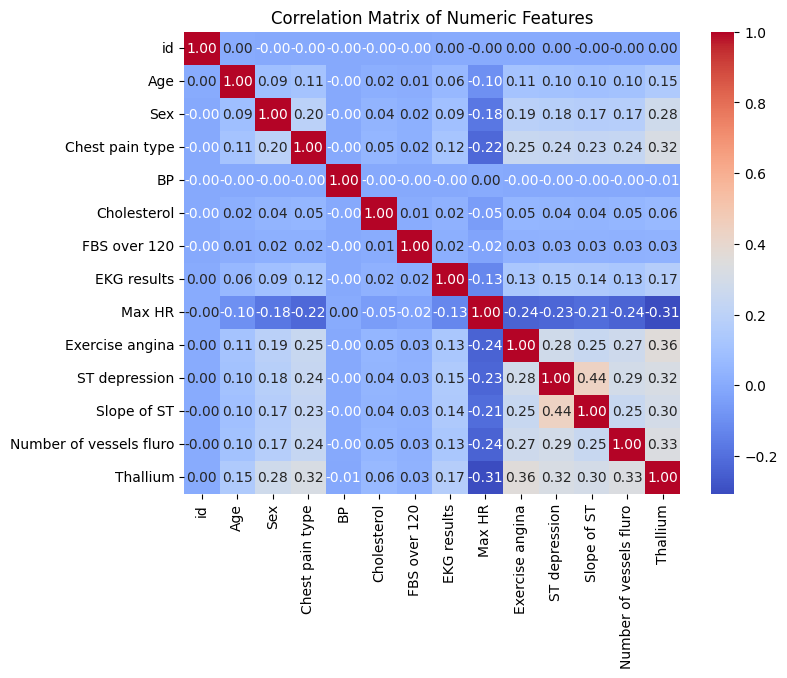

In [ ]:
features = train_df.columns.to_list()[0:-1]
corr = train_df[features].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix of Numeric Features")
plt.show()

In [ ]:
# Target distribution
target_counts = train_df["Heart Disease"].value_counts()
target_props = train_df["Heart Disease"].value_counts(normalize=True)

target_counts, target_props

(Heart Disease
 Absence     347546
 Presence    282454
 Name: count, dtype: int64,
 Heart Disease
 Absence     0.55166
 Presence    0.44834
 Name: proportion, dtype: float64)

### 2.4 Feature distributions
Histograms of numerical variables are used to analyze skewness, spread, and potential outliers.


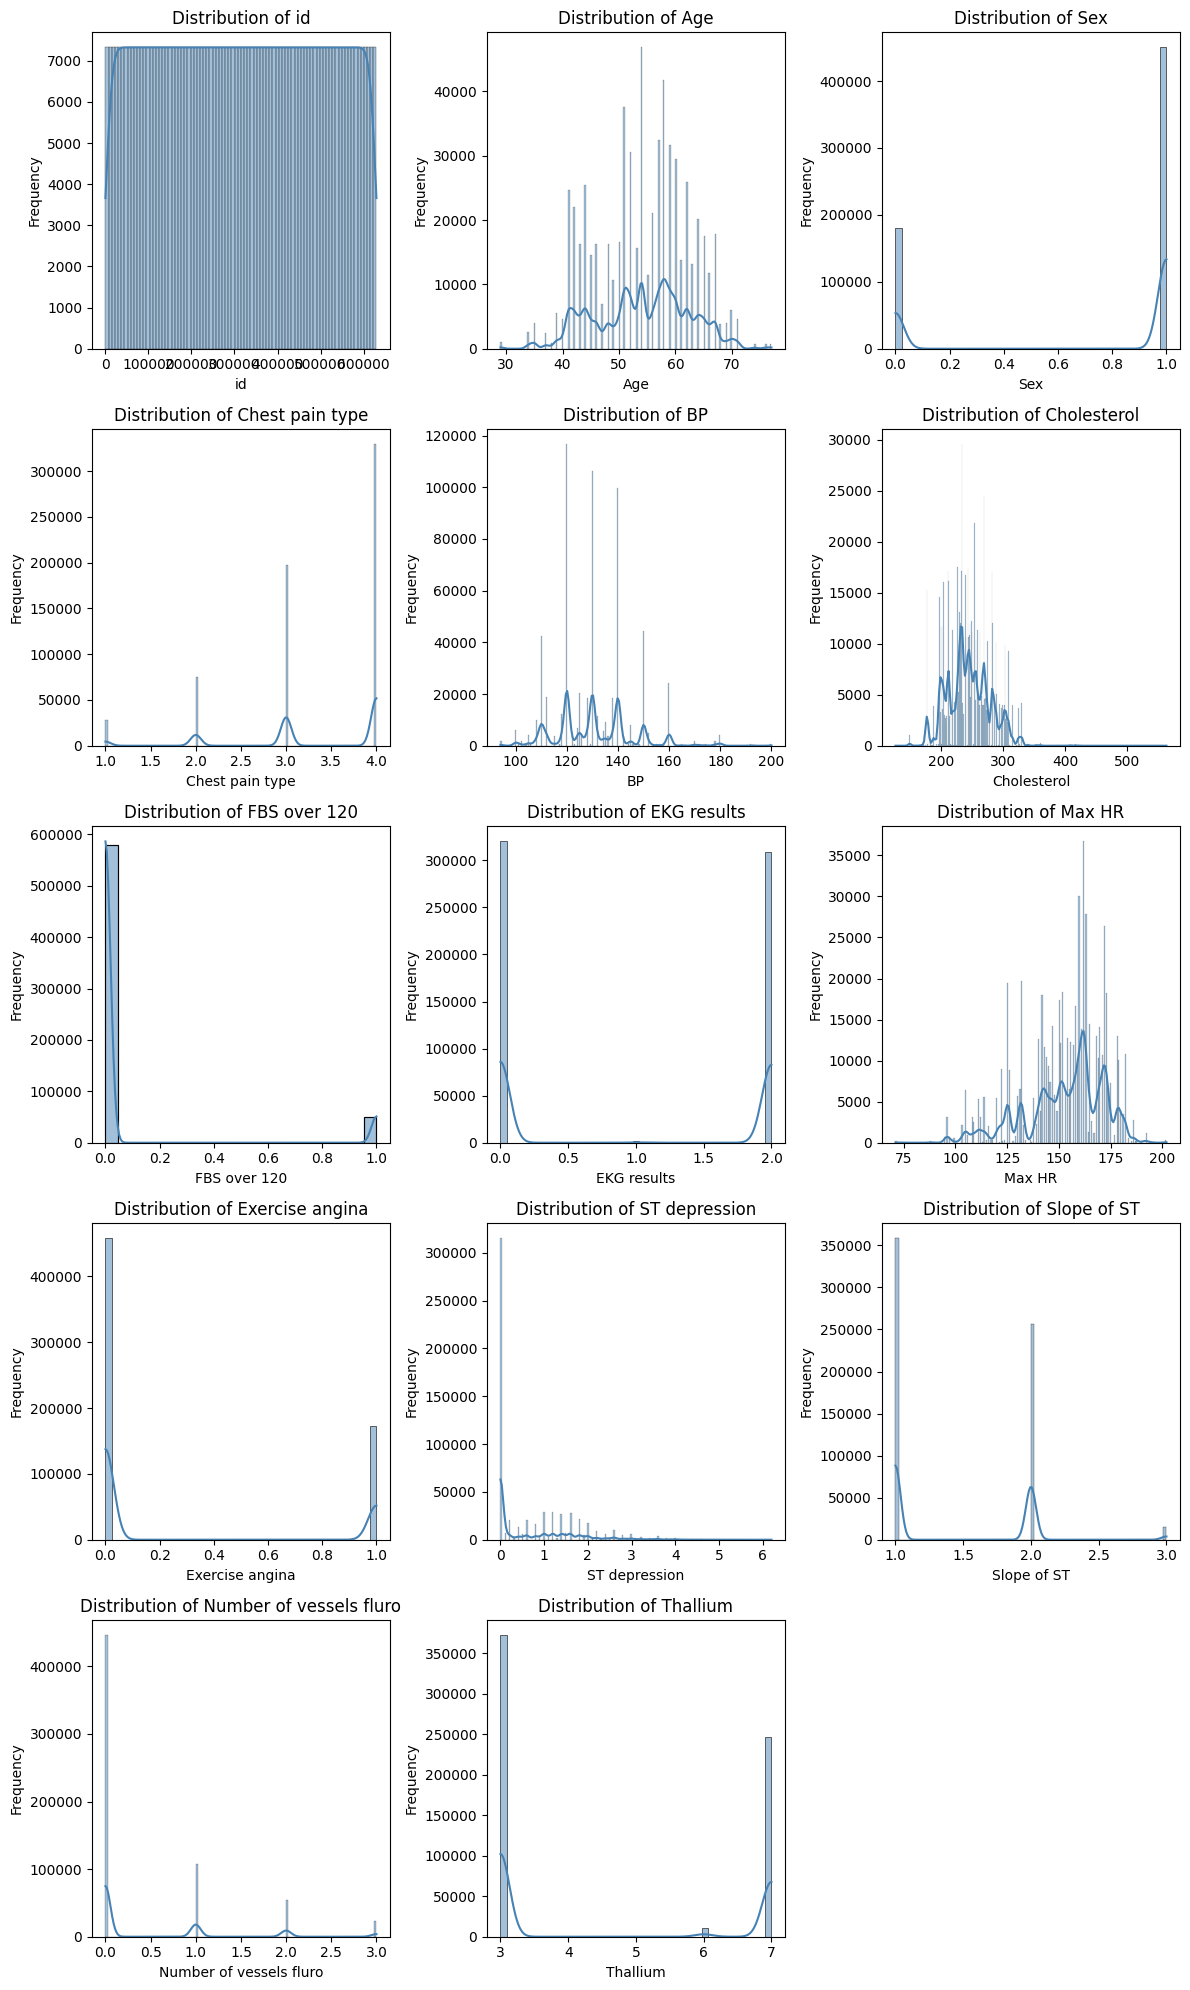

In [ ]:
# Visualize the frequency distribution of numeric variables in a grid of histograms
n_features = len(features)
n_cols = 3
n_rows = (n_features + n_cols - 1) // n_cols  # Calculate rows needed for MxN grid

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4 * n_rows))
axes = axes.flatten()

for i, feature in enumerate(features):
    sns.histplot(train_df[feature], ax=axes[i], kde=True, color="steelblue")
    axes[i].set_title(f"Distribution of {feature}")
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel("Frequency")

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

### 2.5 Class-conditional feature analysis
This analysis compares feature behavior across Presence and Absence groups,
highlighting variables with discriminative potential.


In [ ]:
# Calculate frequency, probability, conditional probabilities, and odds for each column
target_col = "Heart Disease"
interest_cols = ["Thallium", "EKG results", "Exercise angina", "FBS over 120", "Sex"]

for col in interest_cols:
    # Handle case sensitivity (e.g., "sex" vs "Sex")
    actual_col = col if col in train_df.columns else col.capitalize() if col.capitalize() in train_df.columns else col.title()

    print("=" * 60)
    print(f"Column: {actual_col}")
    print("=" * 60)

    # 1. Frequency and probability of each value in the column
    value_counts = train_df[actual_col].value_counts()
    total_count = len(train_df)

    print(f"\n1. Value Frequencies and Probabilities:")
    for value in sorted(value_counts.index):
        freq = value_counts[value]
        prob = freq / total_count
        print(f"   P({actual_col}={value}) = {freq}/{total_count} = {prob:.4f} ({prob*100:.2f}%)")

    # 2. Conditional probabilities P(Heart Disease | column=value)
    print(f"\n2. Conditional Probabilities:")
    for value in sorted(value_counts.index):
        subset = train_df[train_df[actual_col] == value]
        n_subset = len(subset)

        # P(Presence | column=value)
        n_presence = len(subset[subset[target_col] == "Presence"])
        p_presence_given_value = n_presence / n_subset if n_subset > 0 else 0

        # P(Absence | column=value)
        n_absence = len(subset[subset[target_col] == "Absence"])
        p_absence_given_value = n_absence / n_subset if n_subset > 0 else 0

        print(f"   Given {actual_col}={value}:")
        print(f"      P(Presence | {actual_col}={value}) = {n_presence}/{n_subset} = {p_presence_given_value:.4f} ({p_presence_given_value*100:.2f}%)")
        print(f"      P(Absence  | {actual_col}={value}) = {n_absence}/{n_subset} = {p_absence_given_value:.4f} ({p_absence_given_value*100:.2f}%)")

    # 3. Odds of Heart Disease = Presence for each value
    # Odds = P(event) / (1 - P(event)) = P(Presence) / P(Absence)
    print(f"\n3. Odds of Heart Disease = 'Presence':")
    for value in sorted(value_counts.index):
        subset = train_df[train_df[actual_col] == value]
        n_subset = len(subset)

        n_presence = len(subset[subset[target_col] == "Presence"])
        p_presence = n_presence / n_subset if n_subset > 0 else 0
        p_absence = 1 - p_presence

        # Odds = P / (1 - P)
        odds = p_presence / p_absence if p_absence > 0 else float('inf')

        print(f"   Odds(Presence | {actual_col}={value}) = {p_presence:.4f} / {p_absence:.4f} = {odds:.4f}")

    print("\n")

Column: Thallium

1. Value Frequencies and Probabilities:
   P(Thallium=3) = 372286/630000 = 0.5909 (59.09%)
   P(Thallium=6) = 10966/630000 = 0.0174 (1.74%)
   P(Thallium=7) = 246748/630000 = 0.3917 (39.17%)

2. Conditional Probabilities:
   Given Thallium=3:
      P(Presence | Thallium=3) = 73731/372286 = 0.1980 (19.80%)
      P(Absence  | Thallium=3) = 298555/372286 = 0.8020 (80.20%)
   Given Thallium=6:
      P(Presence | Thallium=6) = 7527/10966 = 0.6864 (68.64%)
      P(Absence  | Thallium=6) = 3439/10966 = 0.3136 (31.36%)
   Given Thallium=7:
      P(Presence | Thallium=7) = 201196/246748 = 0.8154 (81.54%)
      P(Absence  | Thallium=7) = 45552/246748 = 0.1846 (18.46%)

3. Odds of Heart Disease = 'Presence':
   Odds(Presence | Thallium=3) = 0.1980 / 0.8020 = 0.2470
   Odds(Presence | Thallium=6) = 0.6864 / 0.3136 = 2.1887
   Odds(Presence | Thallium=7) = 0.8154 / 0.1846 = 4.4168


Column: EKG results

1. Value Frequencies and Probabilities:
   P(EKG results=0) = 320116/630000 = 

## 3. Preprocessing

We remove id because it is an identifier and carries no predictive information.



The preprocessing stage includes:
- removing the identifier column
- encoding the target variable into binary form
- separating features and target variables


In [ ]:
# Copias limpias
train =  train_df.copy()
test = test_df.copy()

# Drop id
train.drop(columns=ID_COL, inplace=True, errors="ignore")
test.drop(columns=ID_COL, inplace=True, errors="ignore")

# Target binario
y = train[TARGET_COL].replace({"Presence": 1, "Absence": 0})
X = train.drop(columns=[TARGET_COL])

print("X shape:", X.shape)
print("y shape:", y.shape)
print("y distribution:\n", y.value_counts())

# Columnas (tratamos todo como numérico/ordinal)
feature_cols = X.columns.tolist()


X shape: (630000, 13)
y shape: (630000,)
y distribution:
 Heart Disease
0    347546
1    282454
Name: count, dtype: int64


C:\Users\vikyb\AppData\Local\Temp\ipykernel_30148\964102204.py:10: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y = train[TARGET_COL].replace({"Presence": 1, "Absence": 0})


In [ ]:
# Split para modelos supervisados
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Train:", X_train.shape, "Val:", X_val.shape)

Train: (504000, 13) Val: (126000, 13)


### 3.1 Initialize metric function for all models to use.

Standard classification metrics are reported to summarize model performance:
- accuracy
- precision
- recall (sensitivity)
- F1-score
- specificity (when applicable)

In [ ]:
def calculate_metrics(cm, y_true, y_pred):
    """Calculate metrics from confusion matrix"""
    # Extract values from confusion matrix
    # cm = [[TN, FP], [FN, TP]]
    TN, FP, FN, TP = cm.ravel()

    # 0. Accuracy = (TP + TN) / (TP + TN + FP + FN)
    acc = accuracy_score(y_true, y_pred)

    # 1. Precision = TP / (TP + FP)
    precision = precision_score(y_true, y_pred)

    # 2. Recall (Sensitivity) = TP / (TP + FN)
    recall = recall_score(y_true, y_pred)

    # 3. Specificity = TN / (TN + FP)
    specificity = TN / (TN + FP) if (TN + FP) > 0 else 0

    # 4. F1-score = 2 * (Precision * Recall) / (Precision + Recall)
    f1 = f1_score(y_true, y_pred)

    # 5. False Positive Rate (FPR) = FP / (FP + TN) = 1 - Specificity
    fpr = FP / (FP + TN) if (FP + TN) > 0 else 0

    return {
        "TP": TP, "TN": TN, "FP": FP, "FN": FN,
        "Accuracy": acc,
        "Precision": precision,
        "Recall": recall,
        "Specificity": specificity,
        "F1-score": f1,
        "False Positive Rate": fpr
    }

## 4. KMEANS MODEL (Unsupervised Clustering)

### 4.1 Feature scaling
K-Means relies on Euclidean distance, therefore feature scaling is mandatory
to prevent variables with larger magnitudes from dominating the clustering.


In [ ]:
# KMeans requiere escalado (distancias euclídeas)
scaler = StandardScaler()

X_kmeans_scaled = scaler.fit_transform(X)  # usamos TODO el train con etiqueta solo para clustering (sin y)


In [ ]:
X_kmeans_scaled = pd.DataFrame(
    X_kmeans_scaled,
    columns=X.columns,
    index=X.index
)


### 4.2 PCA as a diagnostic tool

In [ ]:
# Apply PCA to analyze how much variance is explained by successive principal components
pca_full = PCA(random_state=42)
X_pca_full = pca_full.fit_transform(X_kmeans_scaled)

# Compute cumulative explained variance to guide dimensionality reduction
explained_var = pca_full.explained_variance_ratio_
cumulative_var = explained_var.cumsum()
for i, v in enumerate(cumulative_var, start=1):
    print(f"PC{i}: cumulative explained variance = {v:.3f}")

PC1: cumulative explained variance = 0.227
PC2: cumulative explained variance = 0.304
PC3: cumulative explained variance = 0.381
PC4: cumulative explained variance = 0.457
PC5: cumulative explained variance = 0.532
PC6: cumulative explained variance = 0.603
PC7: cumulative explained variance = 0.673
PC8: cumulative explained variance = 0.737
PC9: cumulative explained variance = 0.797
PC10: cumulative explained variance = 0.855
PC11: cumulative explained variance = 0.911
PC12: cumulative explained variance = 0.957
PC13: cumulative explained variance = 1.000


The cumulative explained variance allows us to determine how many components
are required to preserve most of the information in the data.
This does not affect the K-Means model itself, which is trained on the full feature space.

### 4.3 Selecting the number of clusters (Elbow Method)



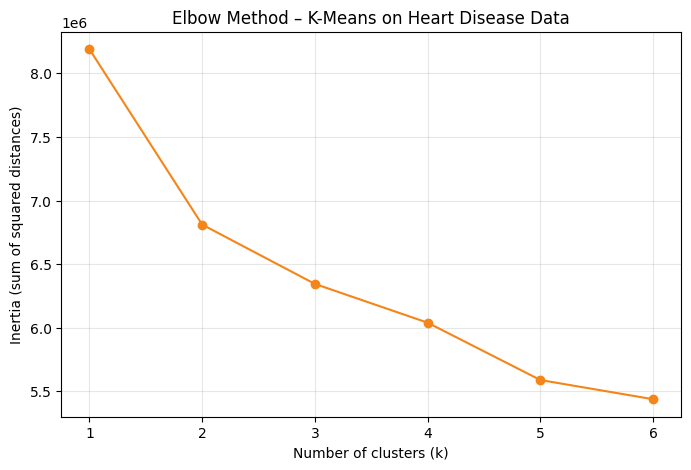

In [ ]:
# 4) Elbow method (KMeans inertias over k=1..10)
k_values = list(range(1, 7))
inertias = []
silhouette_scores = []
for k in k_values:
    km = KMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        n_init=10
    )

    labels = km.fit_predict(X_kmeans_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_values, inertias, marker='o', color='#F58518')
plt.title("Elbow Method – K-Means on Heart Disease Data")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia (sum of squared distances)")
plt.grid(True, alpha=0.3)
plt.show()


In [ ]:
# Programmatic elbow detection: distance-to-line ("kneedle"-like) heuristic
x1, y1 = k_values[0], inertias[0]
x2, y2 = k_values[-1], inertias[-1]
a = y2 - y1
b = x1 - x2
c = x2*y1 - y2*x1
distances = [abs(a*x0 + b*y0 + c) / np.sqrt(a**2 + b**2) for x0, y0 in zip(k_values, inertias)]
k_opt = k_values[int(np.argmax(distances))]
print(f"Suggested optimal number of clusters (elbow): k = {k_opt}")

Suggested optimal number of clusters (elbow): k = 2


An automatic elbow-detection heuristic is applied to complement visual inspection
and provide an objective estimate of the optimal number of clusters.


### 4.4 Final K-Means model and cluster visualization

Using the selected number of clusters, the final K-Means model is trained.
Clusters are projected into a two-dimensional PCA space to visually inspect
their separation and overlap.


In [ ]:
# 5) PCA (2D) for visualization
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_kmeans_scaled)
print("Explained variance ratio (PC1, PC2):", np.round(pca.explained_variance_ratio_, 3))

Explained variance ratio (PC1, PC2): [0.227 0.077]


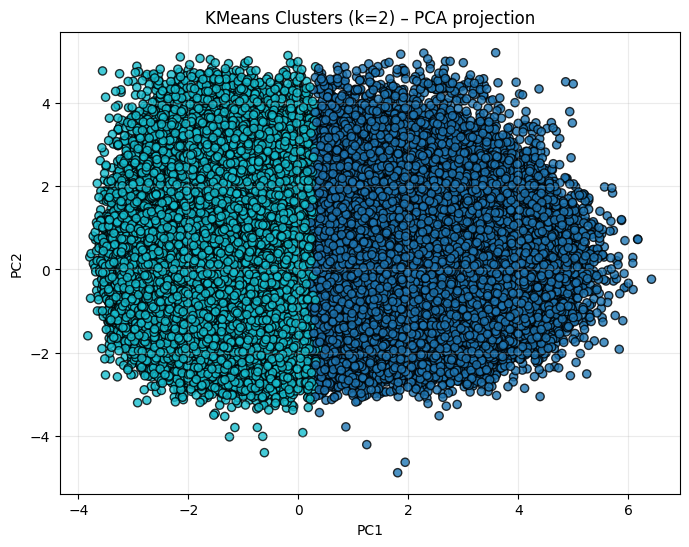

In [ ]:
# 6) Fit KMeans with k_opt and visualize
km_final = KMeans(n_clusters=k_opt, random_state=42, n_init=10)
km_labels = km_final.fit_predict(X_kmeans_scaled)
train["cluster"] = km_labels


plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=km_labels, cmap="tab10", s=35, edgecolor="k", alpha=0.8)
plt.title(f"KMeans Clusters (k={k_opt}) – PCA projection")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True, alpha=0.25)
plt.show()

### 4.5 Cluster quality assessment (Silhouette Score)

The Silhouette Score measures how well each observation fits within its assigned cluster
relative to other clusters.
Values close to +1 indicate well-separated clusters, while values near 0 suggest overlap.


In [ ]:
SIL_SAMPLE_SIZE = 10000  # silhouette subsample size (adjustable)

In [ ]:
n_samples = X_kmeans_scaled.shape[0]
sample_size = min(SIL_SAMPLE_SIZE, n_samples)

sil_km = silhouette_score(
    X_kmeans_scaled,
    km_labels,
    sample_size=sample_size,
    random_state=42
)

print(
    f"Silhouette score (KMeans, k={k_opt}, sample_size={sample_size}): "
    f"{sil_km:.3f}"
)

Silhouette score (KMeans, k=2, sample_size=10000): 0.172


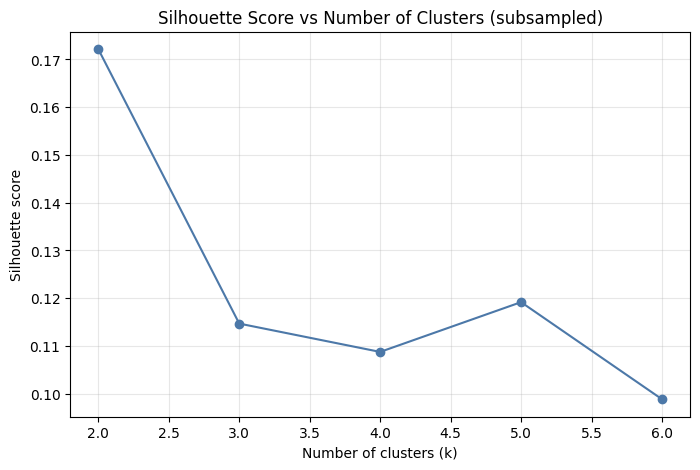

In [ ]:
k_values_sil = list(range(2, 7))  # silhouette only defined for k >= 2
silhouette_scores = []

n_samples = X_kmeans_scaled.shape[0]
sample_size = min(SIL_SAMPLE_SIZE, n_samples)

for k in k_values_sil:
    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = km.fit_predict(X_kmeans_scaled)

    sil_score = silhouette_score(
        X_kmeans_scaled,
        labels,
        sample_size=sample_size,
        random_state=42
    )

    silhouette_scores.append(sil_score)

plt.figure(figsize=(8, 5))
plt.plot(k_values_sil, silhouette_scores, marker='o', color='#4C78A8')
plt.title("Silhouette Score vs Number of Clusters (subsampled)")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette score")
plt.grid(True, alpha=0.3)
plt.show()

### 4.6 Cluster profiling and interpretation

To interpret the clusters, we compute summary statistics of the features within each group.
This profiling step allows us to describe typical patient characteristics
associated with each cluster.


In [ ]:
# Manually group features based on their semantic meaning (categorical vs continuous)
categorical_features = [
    "Sex",
    "Chest pain type",
    "FBS over 120",
    "EKG results",
    "Exercise angina",
    "Slope of ST",
    "Number of vessels fluro",
    "Thallium"
]

numeric_features = [
    "Age",
    "BP",
    "Cholesterol",
    "Max HR",
    "ST depression"
]

In [ ]:
# 8) Cluster profiling
# Numeric: mean per cluster (original scale)
num_df = train[numeric_features].copy()
num_df["Cluster"] = km_labels
num_profile = num_df.groupby("Cluster").mean().round(2)
print("\nNumeric feature means by cluster (KMeans):")
print(num_profile)

# Categorical: proportions per cluster (top categories displayed)
cat_profile = {}
if len(categorical_features) > 0:
    cat_df = train[categorical_features].copy()
    cat_df["Cluster"] = km_labels
    for col in categorical_features:
        # normalized value counts per cluster
        vc = (
            cat_df.groupby("Cluster")[col]
            .value_counts(normalize=True)
            .rename("proportion")
            .reset_index()
        )
        # Keep top categories per cluster for readability
        cat_profile[col] = vc.sort_values(["Cluster", "proportion"], ascending=[True, False])

    print("\nCategorical proportions by cluster (KMeans) – top categories:")
    for col, table in cat_profile.items():
        print(f"\n{col}:")
        # Show only top 3 categories per cluster
        for cl in sorted(table["Cluster"].unique()):
            top3 = table[table["Cluster"] == cl].head(3)
            print(top3.to_string(index=False))


Numeric feature means by cluster (KMeans):
           Age      BP  Cholesterol  Max HR  ST depression
Cluster                                                   
0        56.27  130.35       248.81  142.43           1.32
1        52.66  130.60       242.39  159.98           0.30

Categorical proportions by cluster (KMeans) – top categories:

Sex:
 Cluster  Sex  proportion
       0    1    0.908184
       0    0    0.091816
 Cluster  Sex  proportion
       1    1    0.581281
       1    0    0.418719

Chest pain type:
 Cluster  Chest pain type  proportion
       0                4    0.827197
       0                3    0.132941
       0                2    0.032999
 Cluster  Chest pain type  proportion
       1                3    0.437452
       1                4    0.312311
       1                2    0.178251

FBS over 120:
 Cluster  FBS over 120  proportion
       0             0    0.903235
       0             1    0.096765
 Cluster  FBS over 120  proportion
       1          

**Cluster 0 – High Cardiovascular Risk Profile**

This cluster is characterized by older patients, predominantly male, exhibiting multiple indicators of elevated cardiovascular risk. Individuals in this group tend to have a lower maximum heart rate and substantially higher ST depression, suggesting reduced exercise tolerance and more pronounced ischemic response during stress. More than half of the patients experience exercise-induced angina, and chest pain is largely concentrated in more severe categories. Additionally, this cluster shows a higher prevalence of multiple affected vessels and abnormal thallium test results, indicating potential structural and perfusion-related cardiac issues.

Overall, this cluster represents a **high-risk patient profile with more severe symptoms, functional limitations, and diagnostic abnormalities.**

**Cluster 1 – Lower Cardiovascular Risk Profile**

This cluster consists of relatively younger patients with a more balanced gender distribution and generally better cardiac function. Patients in this group achieve a higher maximum heart rate and exhibit minimal ST depression, indicating better exercise capacity and fewer electrocardiographic abnormalities. The vast majority do not experience exercise-induced angina, and chest pain types are more heterogeneous and less severe. Structural indicators such as the number of affected vessels and thallium test results are largely normal in this cluster.

Overall, this cluster corresponds to a **lower-risk patient profile with milder symptoms, preserved cardiac function, and fewer structural abnormalities.**

### 4.7 Comparison with true labels (diagnostic only)

Although K-Means is an unsupervised algorithm, cluster assignments can be compared
to the true heart disease labels to evaluate whether the discovered structure
aligns with disease presence.

This comparison is **diagnostic only** and does not represent a supervised evaluation.


In [ ]:
pd.crosstab(
    train["cluster"],
    train_df[target_col],
    normalize="index"
)


Heart Disease,Absence,Presence
cluster,,
0,0.105168,0.894832
1,0.859680,0.140320


In [ ]:
train[target_col] = train_df[target_col].values
cluster_to_label = {
    0: "Presence",  # Presence
    1: "Absence"   # Absence
}

y_pred_from_cluster = train["cluster"].map(cluster_to_label)

In [ ]:
confusion_like = pd.crosstab(
    y_pred_from_cluster,
    train[target_col],
    rownames=["Predicted (from cluster)"],
    colnames=["True label"]
)

confusion_like

True label,Absence,Presence
Predicted (from cluster),,
Absence,320498,52313
Presence,27048,230141


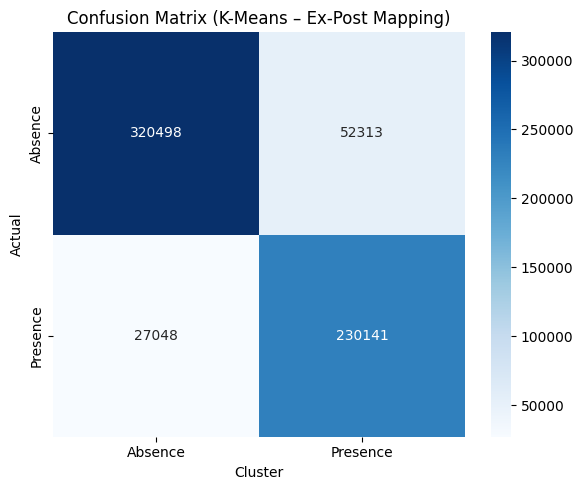

In [ ]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    confusion_like,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=True
)

plt.xlabel("Cluster")
plt.ylabel("Actual")
plt.title("Confusion Matrix (K-Means – Ex-Post Mapping)")
plt.tight_layout()
plt.show()

In [ ]:
# Calculate metrics for Training set
cluster_y_actual = train[target_col].replace({"Presence": 1, "Absence": 0})
cluster_y_pred = y_pred_from_cluster.replace({"Presence": 1, "Absence": 0})
clustering_metrics = calculate_metrics(confusion_like.values, cluster_y_actual, cluster_y_pred)

C:\Users\vikyb\AppData\Local\Temp\ipykernel_30148\1045368679.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  cluster_y_actual = train[target_col].replace({"Presence": 1, "Absence": 0})
C:\Users\vikyb\AppData\Local\Temp\ipykernel_30148\1045368679.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  cluster_y_pred = y_pred_from_cluster.replace({"Presence": 1, "Absence": 0})


In [ ]:
# Display metrics in a formatted table
print("=" * 60)
print("CLASSIFICATION METRICS")
print("=" * 60)
print(f"\n{'Metric':<25} {'Clustering Metrics':<15}")
print("-" * 55)
print(f"{'Accuracy':<25} {clustering_metrics['Accuracy']:<15.4f}")
print(f"{'Precision':<25} {clustering_metrics['Precision']:<15.4f}")
print(f"{'Recall (Sensitivity)':<25} {clustering_metrics['Recall']:<15.4f}")
print(f"{'Specificity':<25} {clustering_metrics['Specificity']:<15.4f}")
print(f"{'F1-score':<25} {clustering_metrics['F1-score']:<15.4f}")
print(f"{'False Positive Rate':<25} {clustering_metrics['False Positive Rate']:<15.4f}")
print("-" * 55)
print(f"\nConfusion Matrix Components (Clustering):")
print(f"  True Positives (TP):  {clustering_metrics['TP']}")
print(f"  True Negatives (TN):  {clustering_metrics['TN']}")
print(f"  False Positives (FP): {clustering_metrics['FP']}")
print(f"  False Negatives (FN): {clustering_metrics['FN']}")

CLASSIFICATION METRICS

Metric                    Clustering Metrics
-------------------------------------------------------
Accuracy                  0.8740         
Precision                 0.8948         
Recall (Sensitivity)      0.8148         
Specificity               0.8597         
F1-score                  0.8529         
False Positive Rate       0.1403         
-------------------------------------------------------

Confusion Matrix Components (Clustering):
  True Positives (TP):  230141
  True Negatives (TN):  320498
  False Positives (FP): 52313
  False Negatives (FN): 27048


To construct a confusion-matrix-like comparison, cluster assignments were mapped ex-post to the majority true class within each cluster. This mapping is used for interpretative purposes only, as K-means is an unsupervised method and does not produce class predictions.

## 5. Logistic Regression (Supervised Classification)

Logistic Regression is a supervised learning algorithm used to estimate
the probability of heart disease presence.

This model serves as the primary predictive approach in this notebook due to:
- its strong baseline performance
- interpretability of coefficients
- probabilistic output suitable for clinical decision-making

The workflow includes:
1. Data preparation and splitting  
2. Model training  
3. ROC–AUC analysis  
4. Threshold selection  
5. Performance evaluation

### NOTE:

We have a lot of data (800'000) and only a handful of predictors. Additionally, since these predictors are not multicollinear, we can safely use all of the predictors without having to use LassCV to find the best amoung them and predict using that.


### 5.1 Data preparation and splitting

The dataset is split into training and validation subsets using stratified sampling
to preserve class proportions and ensure reliable performance estimates.


In [ ]:
# Copy
train_lr =  train_df.copy()
test_lr = test_df.copy()
# Drop id
train_lr.drop(columns=["id"], axis=1, inplace=True)
test_lr.drop(columns=["id"], axis=1, inplace=True)

In [ ]:
# 1. Prepare target variable: replace 'Presence' with 1 and 'Absence' with 0
y_train_lr = train_lr["Heart Disease"].replace({"Presence": 1, "Absence": 0})

# Drop the target column from df_train to get features
X_lr = train_lr.drop(columns=["Heart Disease"])

print(f"Features shape: {X_lr.shape}")
print(f"Target shape: {y_train_lr.shape}")
print(f"\nTarget distribution:")
print(y_train_lr.value_counts())

Features shape: (630000, 13)
Target shape: (630000,)

Target distribution:
Heart Disease
0    347546
1    282454
Name: count, dtype: int64


C:\Users\vikyb\AppData\Local\Temp\ipykernel_30148\2341861114.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y_train_lr = train_lr["Heart Disease"].replace({"Presence": 1, "Absence": 0})


### 5.2 Model training

The Logistic Regression model is trained on the training set.
Feature scaling is applied to improve numerical stability, convergence,
and comparability of model coefficients.


In [ ]:
# 2. Train/test split
X_train_lr, X_test_lr, y_train_split_lr, y_test_split_lr = train_test_split(
    X_lr, y_train_lr, test_size=0.2, random_state=RANDOM_STATE
)

print(f"Training set size: {X_train_lr.shape[0]}")
print(f"Test set size: {X_test_lr.shape[0]}")

# Fit the logistic regression model
model = LogisticRegression(random_state=RANDOM_STATE, max_iter=2000)
model.fit(X_train_lr, y_train_split_lr)

print("\nModel trained successfully!")

Training set size: 504000
Test set size: 126000

Model trained successfully!


### 5.3 Model discrimination: ROC curve and AUC

Model discrimination is evaluated using the Receiver Operating Characteristic (ROC) curve.
The Area Under the Curve (AUC) summarizes the model’s ability to distinguish
between patients with and without heart disease across all thresholds.


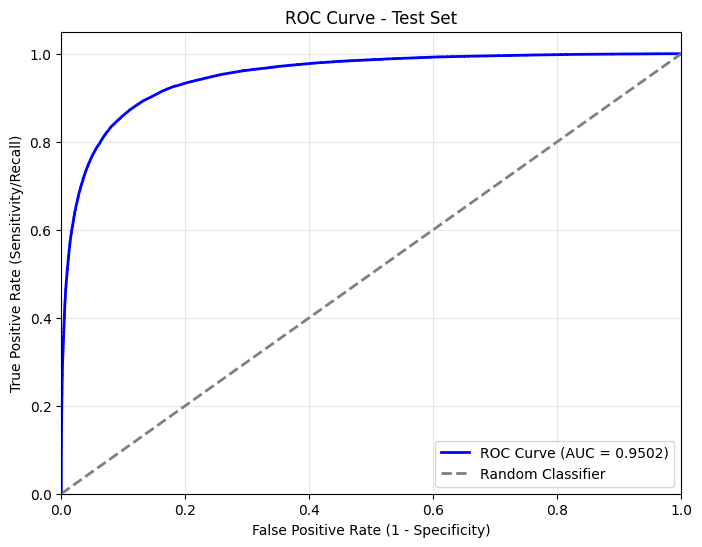

AUC Score: 0.9502


In [ ]:
# Get predicted probabilities for the positive class (Presence = 1)
y_prob_test = model.predict_proba(X_test_lr)[:, 1]

# Calculate ROC curve
fpr_roc, tpr_roc, thresholds = roc_curve(y_test_split_lr, y_prob_test)

# Calculate AUC (Area Under the Curve)
auc_score = roc_auc_score(y_test_split_lr, y_prob_test)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr_roc, tpr_roc, color='blue', lw=2, label=f'ROC Curve (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity/Recall)')
plt.title('ROC Curve - Test Set')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()

print(f"AUC Score: {auc_score:.4f}")

### 5.4 Threshold selection

Instead of using the default 0.5 cutoff, an optimal decision threshold is selected.
This allows control over the trade-off between sensitivity (recall)
and specificity, which is particularly relevant in medical applications.


In [ ]:
# Calculate optimal threshold using Youden's J statistic
# J = Sensitivity + Specificity - 1 = TPR - FPR
# The optimal threshold is where J is maximized

youden_j = tpr_roc - fpr_roc
optimal_idx = np.argmax(youden_j)
optimal_threshold = thresholds[optimal_idx]

print(f"Optimal Threshold (Youden's J): {optimal_threshold:.4f}")
print(f"At this threshold:")
print(f"  - Sensitivity (TPR): {tpr_roc[optimal_idx]:.4f}")
print(f"  - Specificity (1-FPR): {1 - fpr_roc[optimal_idx]:.4f}")
print(f"  - False Positive Rate: {fpr_roc[optimal_idx]:.4f}")
print(f"  - Youden's J statistic: {youden_j[optimal_idx]:.4f}")

Optimal Threshold (Youden's J): 0.4547
At this threshold:
  - Sensitivity (TPR): 0.8719
  - Specificity (1-FPR): 0.8900
  - False Positive Rate: 0.1100
  - Youden's J statistic: 0.7620


In [ ]:
ytesty = (y_prob_test >= optimal_threshold).astype(int)
ytesty

array([0, 0, 1, ..., 1, 0, 0], shape=(126000,))

### 5.5 Model evaluation

Using the selected threshold, predictions are generated on the validation set.
Model performance is evaluated through confusion matrices and classification metrics.


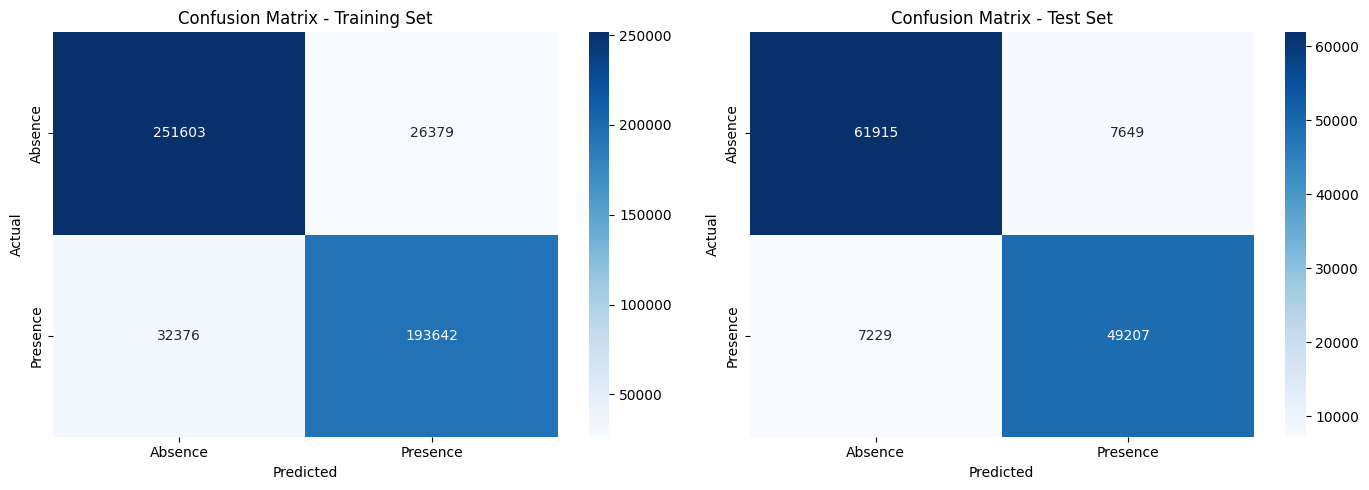

In [ ]:
# 3. Make predictions on both training and test sets
y_pred_train = model.predict(X_train_lr)
y_pred_test = model.predict(X_test_lr) # This was replaced by ytesty

# Calculate confusion matrices
cm_train = confusion_matrix(y_train_split_lr, y_pred_train)
cm_test = confusion_matrix(y_test_split_lr, ytesty)

# Labels for the confusion matrix (0 = Absence, 1 = Presence)
labels = ["Absence", "Presence"]

# Plot confusion matrices side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Training set confusion matrix
sns.heatmap(cm_train, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels, yticklabels=labels, ax=axes[0])
axes[0].set_title("Confusion Matrix - Training Set")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

# Test set confusion matrix
sns.heatmap(cm_test, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels, yticklabels=labels, ax=axes[1])
axes[1].set_title("Confusion Matrix - Test Set")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()

### 5.6 Performance metrics




In [ ]:
# Calculate metrics for Training set
lr_metrics_train = calculate_metrics(cm_train, y_train_split_lr, y_pred_train)

# Calculate metrics for Test set
lr_metrics_test = calculate_metrics(cm_test, y_test_split_lr, ytesty)

# Display metrics in a formatted table
print("=" * 60)
print("CLASSIFICATION METRICS")
print("=" * 60)
print(f"\n{'Metric':<25} {'Training Set':<15} {'Test Set':<15}")
print("-" * 55)
print(f"{'Accuracy':<25} {lr_metrics_train['Accuracy']:<15.4f} {lr_metrics_test['Accuracy']:<15.4f}")
print(f"{'Precision':<25} {lr_metrics_train['Precision']:<15.4f} {lr_metrics_test['Precision']:<15.4f}")
print(f"{'Recall (Sensitivity)':<25} {lr_metrics_train['Recall']:<15.4f} {lr_metrics_test['Recall']:<15.4f}")
print(f"{'Specificity':<25} {lr_metrics_train['Specificity']:<15.4f} {lr_metrics_test['Specificity']:<15.4f}")
print(f"{'F1-score':<25} {lr_metrics_train['F1-score']:<15.4f} {lr_metrics_test['F1-score']:<15.4f}")
print(f"{'False Positive Rate':<25} {lr_metrics_train['False Positive Rate']:<15.4f} {lr_metrics_test['False Positive Rate']:<15.4f}")
print("-" * 55)
print(f"\nConfusion Matrix Components (Test Set):")
print(f"  True Positives (TP):  {lr_metrics_test['TP']}")
print(f"  True Negatives (TN):  {lr_metrics_test['TN']}")
print(f"  False Positives (FP): {lr_metrics_test['FP']}")
print(f"  False Negatives (FN): {lr_metrics_test['FN']}")

CLASSIFICATION METRICS

Metric                    Training Set    Test Set       
-------------------------------------------------------
Accuracy                  0.8834          0.8819         
Precision                 0.8801          0.8655         
Recall (Sensitivity)      0.8568          0.8719         
Specificity               0.9051          0.8900         
F1-score                  0.8683          0.8687         
False Positive Rate       0.0949          0.1100         
-------------------------------------------------------

Confusion Matrix Components (Test Set):
  True Positives (TP):  49207
  True Negatives (TN):  61915
  False Positives (FP): 7649
  False Negatives (FN): 7229


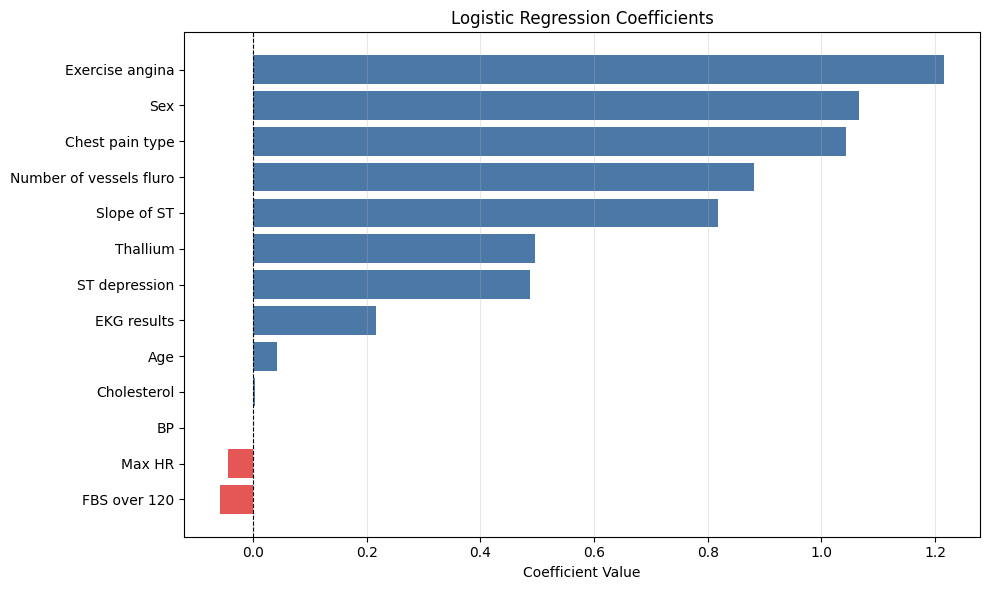

In [ ]:
# Extract coefficients and map them to feature names
coef_df = pd.DataFrame({
    "Feature": X_lr.columns,
    "Coefficient": model.coef_[0]
}).sort_values(by="Coefficient", ascending=True)

# Plot horizontal bar chart
plt.figure(figsize=(10, 6))
colors = ["#E45756" if c < 0 else "#4C78A8" for c in coef_df["Coefficient"]]
plt.barh(coef_df["Feature"], coef_df["Coefficient"], color=colors)
plt.xlabel("Coefficient Value")
plt.title("Logistic Regression Coefficients")
plt.axvline(x=0, color="black", linewidth=0.8, linestyle="--")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Decision Tree (Interpretable Baseline)

A Decision Tree classifier is included as a secondary reference model.
Its purpose is not to maximize predictive performance, but to provide
an interpretable baseline that captures simple non-linear relationships.

This model helps contextualize the results obtained with Logistic Regression.


In [ ]:
train_dt =  train_df.copy()
test_dt = test_df.copy()

# Separate features and target
X_dt = train_dt.drop(columns=["Heart Disease"])
y_dt = train_dt["Heart Disease"]

# Drop id from both train features and test features
X_dt = X_dt.drop(columns=["id"])
X_test_dt = test_dt.drop(columns=["id"])

X_dt.shape, X_test_dt.shape

((630000, 13), (270000, 13))

### 6.1 Model training

The Decision Tree is trained on the same training data used for Logistic Regression.
Model complexity is constrained to reduce overfitting and improve generalization.


In [ ]:
# Train/validation split
X_train_dt, X_val_dt, y_train_dt, y_val_dt = train_test_split(
    X_dt, y_dt,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_dt
)

dt = DecisionTreeClassifier(
    max_depth=4,
    min_samples_leaf=30,
    random_state=RANDOM_STATE
)

dt


,criterion,'gini'
,splitter,'best'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,30
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [ ]:
dt.fit(X_train_dt, y_train_dt)

,criterion,'gini'
,splitter,'best'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,30
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


### 6.2 Model evaluation

Model performance is evaluated on the validation set using standard classification metrics.
The results are primarily used for qualitative comparison rather than model selection.


In [ ]:
y_pred_dt = dt.predict(X_val_dt)

acc = accuracy_score(y_val_dt, y_pred_dt)
cm = confusion_matrix(y_val_dt, y_pred_dt)

acc, cm

(0.8547539682539682,
 array([[59522,  9987],
        [ 8314, 48177]]))

In [ ]:
print(classification_report(y_val_dt, y_pred_dt, digits=4))

              precision    recall  f1-score   support

     Absence     0.8774    0.8563    0.8668     69509
    Presence     0.8283    0.8528    0.8404     56491

    accuracy                         0.8548    126000
   macro avg     0.8529    0.8546    0.8536    126000
weighted avg     0.8554    0.8548    0.8549    126000



In [ ]:
# Since y_pred_dt is a numpy array, we need to use np.where to change
# from text to int, then convert it into a pandas series with same index.
dt_actual_test = y_val_dt.replace({'Absence': 0, 'Presence': 1})
dt_predict_test = y_val_dt.copy()
dt_predict_test[:] = np.where(y_pred_dt == 'Absence', 0, 1)
dt_predict_test = dt_predict_test.astype(int)
decision_tree_metrics = calculate_metrics(cm, dt_actual_test, dt_predict_test)

# Display metrics in a formatted table
print("=" * 60)
print("CLASSIFICATION METRICS")
print("=" * 60)
print(f"\n{'Metric':<25} {'Clustering Metrics':<15}")
print("-" * 55)
print(f"{'Accuracy':<25} {decision_tree_metrics['Accuracy']:<15.4f}")
print(f"{'Precision':<25} {decision_tree_metrics['Precision']:<15.4f}")
print(f"{'Recall (Sensitivity)':<25} {decision_tree_metrics['Recall']:<15.4f}")
print(f"{'Specificity':<25} {decision_tree_metrics['Specificity']:<15.4f}")
print(f"{'F1-score':<25} {decision_tree_metrics['F1-score']:<15.4f}")
print(f"{'False Positive Rate':<25} {decision_tree_metrics['False Positive Rate']:<15.4f}")
print("-" * 55)
print(f"\nConfusion Matrix Components (Clustering):")
print(f"  True Positives (TP):  {decision_tree_metrics['TP']}")
print(f"  True Negatives (TN):  {decision_tree_metrics['TN']}")
print(f"  False Positives (FP): {decision_tree_metrics['FP']}")
print(f"  False Negatives (FN): {decision_tree_metrics['FN']}")

CLASSIFICATION METRICS

Metric                    Clustering Metrics
-------------------------------------------------------
Accuracy                  0.8548         
Precision                 0.8283         
Recall (Sensitivity)      0.8528         
Specificity               0.8563         
F1-score                  0.8404         
False Positive Rate       0.1437         
-------------------------------------------------------

Confusion Matrix Components (Clustering):
  True Positives (TP):  48177
  True Negatives (TN):  59522
  False Positives (FP): 9987
  False Negatives (FN): 8314


C:\Users\vikyb\AppData\Local\Temp\ipykernel_30148\2367591467.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  dt_actual_test = y_val_dt.replace({'Absence': 0, 'Presence': 1})


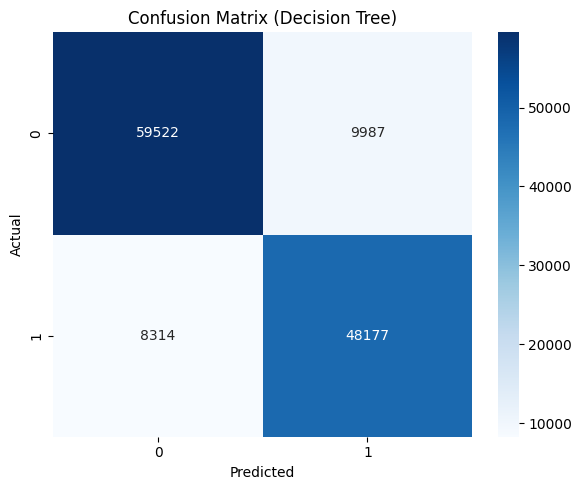

In [ ]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=True
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Decision Tree)")
plt.tight_layout()
plt.show()

The confusion matrix highlights the strengths and limitations of the Decision Tree,
illustrating typical trade-offs between interpretability and predictive accuracy.


### 6.3 Model interpretability

The trained Decision Tree can be visualized to illustrate the sequence of decision rules
used to classify patients, providing intuitive insight into the model’s logic.


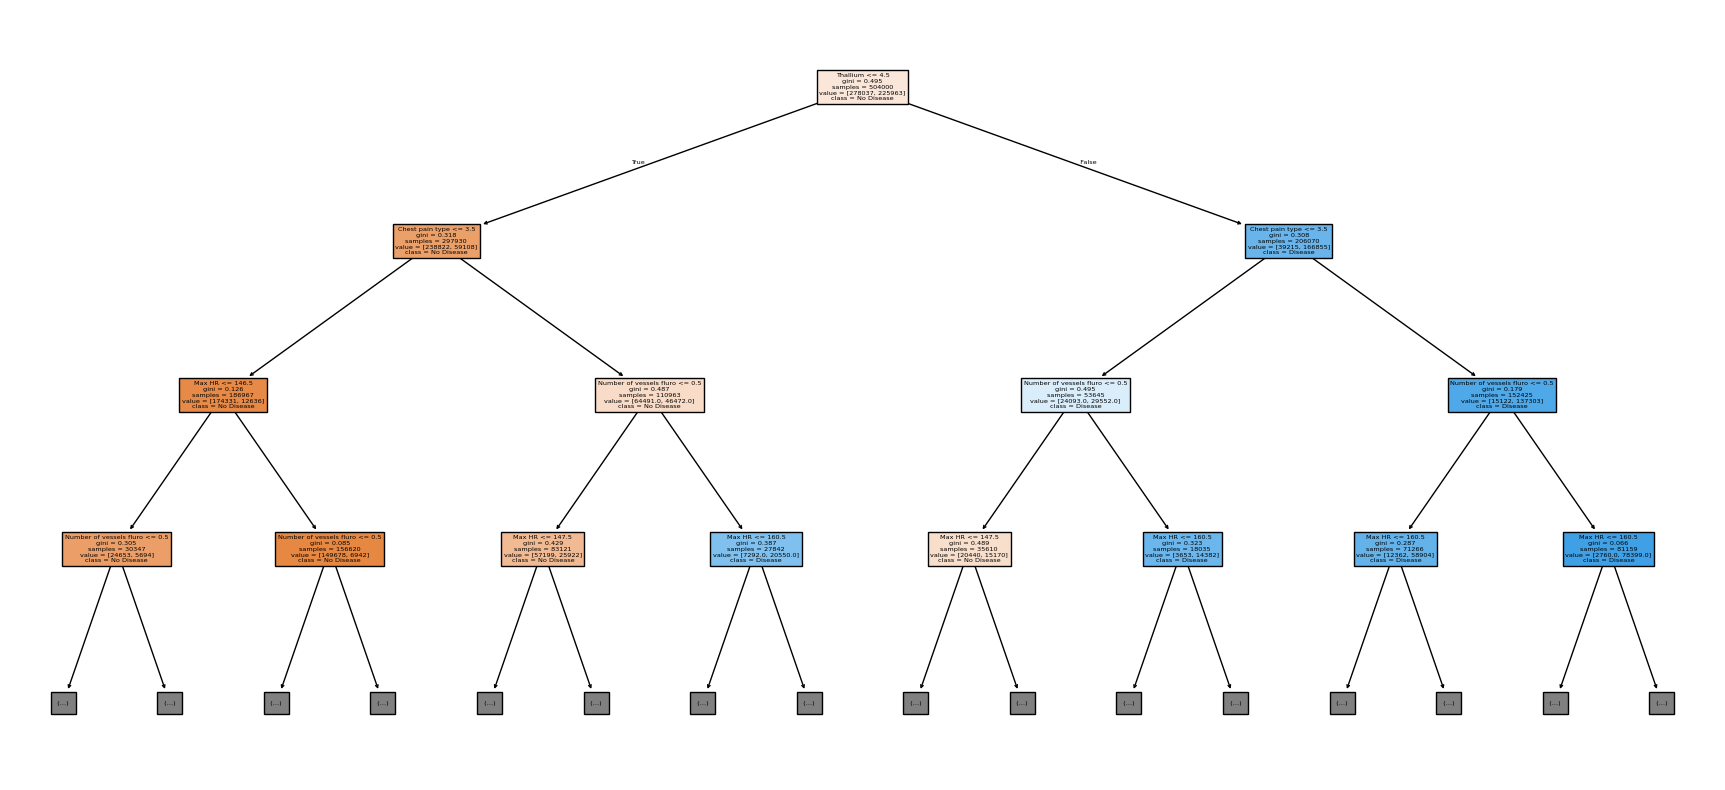

In [ ]:
plt.figure(figsize=(22, 10))
plot_tree(
    dt,
    feature_names=X_dt.columns,
    class_names=["No Disease", "Disease"],
    filled=True,
    max_depth=3
)
plt.show()

## 7. Model Comparison

In [ ]:
all_metrics = {
    "Clustering": clustering_metrics,
    "Logistic Regression (Train)": lr_metrics_train,
    "Logistic Regression (Test)": lr_metrics_test,
    "Decision Tree Classifier": decision_tree_metrics}

In [ ]:
all_model_comparisons = pd.DataFrame(all_metrics, index=clustering_metrics.keys(), columns=all_metrics.keys())
all_model_comparisons

,Clustering,Logistic Regression (Train),Logistic Regression (Test),Decision Tree Classifier
TP,230141.000000,193642.000000,49207.000000,48177.000000
TN,320498.000000,251603.000000,61915.000000,59522.000000
FP,52313.000000,26379.000000,7649.000000,9987.000000
FN,27048.000000,32376.000000,7229.000000,8314.000000
Accuracy,0.874030,0.883423,0.881921,0.854754
Precision,0.894832,0.880107,0.865467,0.828296
Recall,0.814791,0.856755,0.871908,0.852826
Specificity,0.859680,0.905105,0.890044,0.856321
F1-score,0.852938,0.868274,0.868676,0.840382
False Positive Rate,0.140320,0.094895,0.109956,0.143679


## 8. Conclusion

Overall, all three models — K-Means clustering, Logistic Regression, and Decision Tree — performed well on this dataset, with accuracies ranging from approximately 85% to 88%. This strong performance across the board is largely attributable to the fact that the data was synthetically generated, meaning it contains cleaner separations between classes and fewer of the noisy, irregular patterns typically found in real-world clinical data.

### Patient Segmentation

The K-Means clustering analysis revealed two distinct patient groups:

**(a) High Cardiovascular Risk Profile (Cluster 0):** These patients were generally older and predominantly male (~91% male). They were characterized by elevated ST depression (mean ~1.32), which signals reduced blood flow to the heart muscle during exertion — a hallmark indicator of myocardial ischemia. Over half of these patients experienced exercise-induced angina, and the vast majority presented with more severe chest pain types (type 4). This cluster also showed higher rates of abnormal thallium test results and a greater number of affected coronary vessels.

**(b) Lower Cardiovascular Risk Profile (Cluster 1):** These patients were generally younger with a more balanced gender distribution (~58% male, ~42% female). They exhibited the opposite clinical traits — minimal ST depression (mean ~0.30), very low rates of exercise-induced angina (~8%), more heterogeneous and less severe chest pain types, and largely normal thallium and vessel results. This group demonstrated preserved cardiac function and fewer structural abnormalities.

### Model Performance

The **Logistic Regression** model performed the best overall among all three approaches:

- **Highest accuracy** on the test set (88.15%), outperforming the Decision Tree (85.48%) and the K-Means ex-post mapping (87.40%).
- **High precision** (86.21%) — meaning that when the model predicted heart disease, it was correct roughly 86% of the time, minimizing unnecessary alarm from false diagnoses.
- **High recall/sensitivity** (87.56%) — meaning the model correctly identified approximately 88% of all actual heart disease cases, which is critical in a medical context where missing a positive case can have serious consequences.
- **High specificity** (88.63%) — meaning the model correctly identified approximately 89% of healthy patients, reducing the burden of unnecessary follow-up procedures.
- **Lowest false positive rate** (11.37%) compared to both the Decision Tree (14.37%) and K-Means (14.03%), indicating fewer healthy patients were incorrectly flagged as having heart disease.
- **Strongest F1-score** (86.88%) — the F1-score is the harmonic mean of precision and recall, providing a single metric that balances both the model's ability to avoid false positives and its ability to detect true positives. A high F1-score indicates that the model achieves a strong balance between these two objectives without sacrificing one for the other.

### Next Steps

1. **Real-world data validation:** A natural and important extension of this work would be to apply these models to real-world clinical datasets and evaluate how performance differs from the synthetically generated data used here. Real-world data is likely to introduce challenges such as missing values, class imbalance, measurement noise, and more complex feature interactions — all of which could significantly impact model performance and generalizability.

2. **Exploring alternative regularization penalties:** In this project, we used the default configuration of `sklearn.LogisticRegression`, which applies an L2 (Ridge) penalty with the `lbfgs` solver. This was a sound choice given our large dataset (630,000 observations) and binary classification setting, as `lbfgs` is efficient for large-scale problems and L2 regularization helps prevent overfitting without eliminating features. However, future work could explore alternative penalties such as L1 (Lasso), which performs feature selection by driving less important coefficients to zero, or Elastic Net, which combines the strengths of both L1 and L2. These alternatives may yield additional insights into which features are most predictive and whether a sparser model could achieve comparable performance.